# CAPM Analysis for 10 U.S. Stocks

This notebook estimates and compares the CAPM alpha and beta of ten U.S. stocks from different sectors.

- Market portfolio: S&P 500
- Risk-free rate: 3-month U.S. Treasury rate
- Data frequency: Daily
- Sample period: 2016-2025

## 1. Setup

Import the Python libraries required for data inspection, visualization, and CAPM regression.

In [57]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Data Loading and Initial Inspection

Load the processed CAPM dataset. Price returns, the daily risk-free rate, and excess returns were already calculated in `src/download_data.py`; this notebook does not repeat those preprocessing steps.

In [58]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "capm_daily_data.csv"

print("Data path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

Data path: c:\Users\Lenovo\Documents\ChatGPT\quant\CAPM\data\processed\capm_daily_data.csv
File exists: True


In [59]:
capm_data = pd.read_csv(
    DATA_PATH,
    parse_dates=["Date"],
    index_col="Date",
)

display(capm_data.head())
print("Shape:", capm_data.shape)
print("Start date:", capm_data.index.min())
print("End date:", capm_data.index.max())
capm_data.info()

,AAPL_return,JPM_return,JNJ_return,XOM_return,PG_return,CAT_return,NEE_return,AMZN_return,LIN_return,PLD_return,market_return,rf_annual_pct,rf_daily,market_excess,AAPL_excess,JPM_excess,JNJ_excess,XOM_excess,PG_excess,CAT_excess,NEE_excess,AMZN_excess,LIN_excess,PLD_excess
Date,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-0.025059,0.001729,0.004180,0.008520,0.003190,-0.010443,0.009752,-0.005024,-0.003442,0.021003,0.002012,0.20,0.000008,0.002004,-0.025067,0.001721,0.004172,0.008512,0.003182,-0.010451,0.009744,-0.005032,-0.003450,0.020995
2016-01-06,-0.019570,-0.014436,-0.005055,-0.008321,-0.009667,-0.015755,-0.003251,-0.001799,-0.010067,-0.005377,-0.013115,0.21,0.000008,-0.013124,-0.019578,-0.014444,-0.005063,-0.008329,-0.009675,-0.015763,-0.003259,-0.001807,-0.010075,-0.005385
2016-01-07,-0.042205,-0.040440,-0.011654,-0.016006,-0.008733,-0.034431,0.004413,-0.039058,-0.025025,-0.026087,-0.023700,0.20,0.000008,-0.023708,-0.042213,-0.040448,-0.011662,-0.016014,-0.008741,-0.034439,0.004405,-0.039066,-0.025033,-0.026095
2016-01-08,0.005288,-0.022399,-0.010683,-0.020202,-0.015678,-0.010166,0.004489,-0.001464,0.000613,-0.008928,-0.010838,0.20,0.000008,-0.010846,0.005280,-0.022407,-0.010691,-0.020210,-0.015686,-0.010174,0.004481,-0.001472,0.000605,-0.008936
2016-01-11,0.016192,-0.001527,-0.006010,-0.013388,0.009214,-0.028757,0.003898,0.017610,0.006030,-0.001217,0.000853,0.21,0.000008,0.000845,0.016184,-0.001536,-0.006019,-0.013397,0.009206,-0.028765,0.003890,0.017601,0.006021,-0.001226


Shape: (2513, 24)
Start date: 2016-01-05 00:00:00
End date: 2025-12-31 00:00:00
<class 'pandas.DataFrame'>
DatetimeIndex: 2513 entries, 2016-01-05 to 2025-12-31
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AAPL_return    2513 non-null   float64
 1   JPM_return     2513 non-null   float64
 2   JNJ_return     2513 non-null   float64
 3   XOM_return     2513 non-null   float64
 4   PG_return      2513 non-null   float64
 5   CAT_return     2513 non-null   float64
 6   NEE_return     2513 non-null   float64
 7   AMZN_return    2513 non-null   float64
 8   LIN_return     2513 non-null   float64
 9   PLD_return     2513 non-null   float64
 10  market_return  2513 non-null   float64
 11  rf_annual_pct  2513 non-null   float64
 12  rf_daily       2513 non-null   float64
 13  market_excess  2513 non-null   float64
 14  AAPL_excess    2513 non-null   float64
 15  JPM_excess     2513 non-null   float64
 16  JNJ_exces

## 3. Data Quality Checks

Confirm that the processed dataset is complete and suitable for time-series regression.

In [60]:
quality_checks = pd.Series(
    {
        "Number of rows": len(capm_data),
        "Number of columns": capm_data.shape[1],
        "Missing values": capm_data.isna().sum().sum(),
        "Duplicate dates": capm_data.index.duplicated().sum(),
        "Duplicate rows": capm_data.duplicated().sum(),
        "Dates sorted": capm_data.index.is_monotonic_increasing,
    },
    name="Result",
)

quality_checks

Number of rows       2513
Number of columns      24
Missing values          0
Duplicate dates         0
Duplicate rows          0
Dates sorted         True
Name: Result, dtype: object

In [61]:
stock_return_columns = [
    column
    for column in capm_data.columns
    if column.endswith("_return") and column != "market_return"
]

return_ranges = capm_data[stock_return_columns].agg(["min", "max"]).T
return_ranges

,min,max
AAPL_return,-0.128647,0.153288
JPM_return,-0.149649,0.180125
JNJ_return,-0.100379,0.079977
XOM_return,-0.122247,0.126868
PG_return,-0.087373,0.120090
CAT_return,-0.142822,0.116346
NEE_return,-0.134171,0.136904
AMZN_return,-0.140494,0.135359
LIN_return,-0.102833,0.116948
PLD_return,-0.172706,0.118103


## 4. Descriptive Statistics

Summarize and compare the return and volatility characteristics of the ten stocks.

In [62]:
daily_statistics = capm_data[stock_return_columns].describe().T
daily_statistics

,count,mean,std,min,25%,50%,75%,max
AAPL_return,2513.0,0.001138,0.018300,-0.128647,-0.007080,0.001095,0.010028,0.153288
JPM_return,2513.0,0.000901,0.017373,-0.149649,-0.006986,0.000764,0.008935,0.180125
JNJ_return,2513.0,0.000465,0.011567,-0.100379,-0.004743,0.000474,0.005940,0.079977
XOM_return,2513.0,0.000504,0.017551,-0.122247,-0.008183,0.000458,0.009248,0.126868
PG_return,2513.0,0.000419,0.011805,-0.087373,-0.005121,0.000668,0.006349,0.120090
CAT_return,2513.0,0.001129,0.019135,-0.142822,-0.008511,0.000841,0.011104,0.116346
NEE_return,2513.0,0.000678,0.015859,-0.134171,-0.006658,0.001197,0.008305,0.136904
AMZN_return,2513.0,0.001001,0.020662,-0.140494,-0.008801,0.001163,0.011379,0.135359
LIN_return,2513.0,0.000745,0.014438,-0.102833,-0.006289,0.000620,0.007741,0.116948
PLD_return,2513.0,0.000704,0.017041,-0.172706,-0.007646,0.001131,0.009539,0.118103


In [63]:
annualized_statistics = pd.DataFrame(
    {
        "annualized_return": capm_data[stock_return_columns].mean() * 252,
        "annualized_volatility": capm_data[stock_return_columns].std() * np.sqrt(252),
    }
)

annualized_statistics.sort_values(
    by="annualized_return",
    ascending=False,
)

,annualized_return,annualized_volatility
AAPL_return,0.286677,0.290508
CAT_return,0.284568,0.303762
AMZN_return,0.252347,0.327994
JPM_return,0.227134,0.275794
LIN_return,0.187665,0.229195
PLD_return,0.177287,0.270512
NEE_return,0.170965,0.251753
XOM_return,0.126946,0.278615
JNJ_return,0.117132,0.183623
PG_return,0.105659,0.187402


## 5. Risk-Free Rate

The processed dataset already contains the annualized FRED `DGS3MO` rate (`rf_annual_pct`) and its daily equivalent (`rf_daily`). The conversion was performed during preprocessing so that the risk-free rate has the same frequency as stock and market returns.

,count,mean,std,min,25%,50%,75%,max
rf_annual_pct,2513.0,2.247967,1.968300,0.0,0.320000,1.77000,4.330000,5.630000
rf_daily,2513.0,0.000087,0.000076,0.0,0.000013,0.00007,0.000168,0.000217


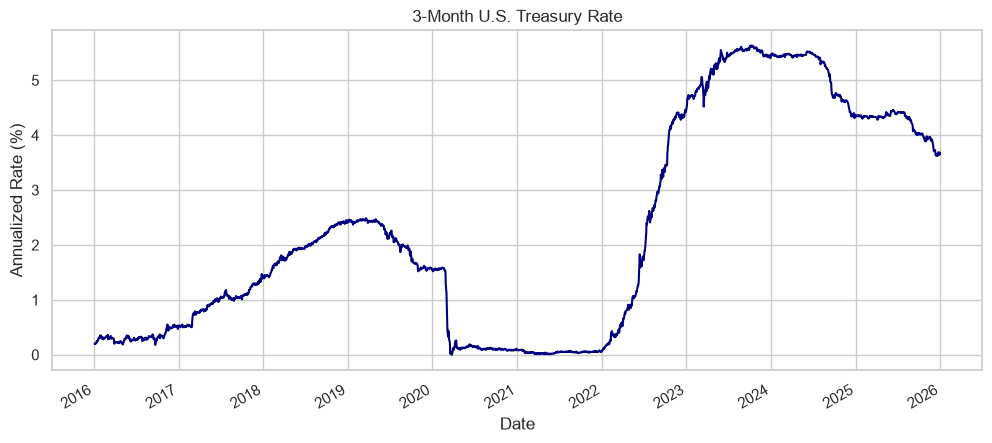

In [64]:
display(capm_data[["rf_annual_pct", "rf_daily"]].describe().T)

fig, ax = plt.subplots(figsize=(12, 5))
capm_data["rf_annual_pct"].plot(
    ax=ax,
    color="navy",
    linewidth=1.5,
)
ax.set_title("3-Month U.S. Treasury Rate")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Rate (%)")
plt.show()

## 6. CAPM Variables

The processed dataset already contains daily stock and market excess returns. During preprocessing, they were calculated as:

\[R_{i,t}^{e}=R_{i,t}-R_{f,t}\]

\[R_{m,t}^{e}=R_{m,t}-R_{f,t}\]

The existing `*_excess` columns are used directly in the regressions below.

In [65]:
stock_tickers = [
    "AAPL", "JPM", "JNJ", "XOM", "PG",
    "CAT", "NEE", "AMZN", "LIN", "PLD",
]

required_capm_columns = ["market_excess"] + [
    f"{ticker}_excess" for ticker in stock_tickers
]
missing_capm_columns = [
    column for column in required_capm_columns if column not in capm_data.columns
]

print("Missing CAPM columns:", missing_capm_columns)
capm_data[required_capm_columns].head()

Missing CAPM columns: []


,market_excess,AAPL_excess,JPM_excess,JNJ_excess,XOM_excess,PG_excess,CAT_excess,NEE_excess,AMZN_excess,LIN_excess,PLD_excess
Date,,,,,,,,,,,
2016-01-05,0.002004,-0.025067,0.001721,0.004172,0.008512,0.003182,-0.010451,0.009744,-0.005032,-0.003450,0.020995
2016-01-06,-0.013124,-0.019578,-0.014444,-0.005063,-0.008329,-0.009675,-0.015763,-0.003259,-0.001807,-0.010075,-0.005385
2016-01-07,-0.023708,-0.042213,-0.040448,-0.011662,-0.016014,-0.008741,-0.034439,0.004405,-0.039066,-0.025033,-0.026095
2016-01-08,-0.010846,0.005280,-0.022407,-0.010691,-0.020210,-0.015686,-0.010174,0.004481,-0.001472,0.000605,-0.008936
2016-01-11,0.000845,0.016184,-0.001536,-0.006019,-0.013397,0.009206,-0.028765,0.003890,0.017601,0.006021,-0.001226


## 7. CAPM Regressions

For each stock, estimate:

\[R_{i,t}-R_{f,t}=\alpha_i+\beta_i(R_{m,t}-R_{f,t})+\epsilon_{i,t}\]

Each stock's processed excess return is the dependent variable, while `market_excess` is the common independent variable.

In [66]:
X = sm.add_constant(capm_data[["market_excess"]])
capm_models = {}
capm_result_rows = []

for ticker in stock_tickers:
    y = capm_data[f"{ticker}_excess"]
    model = sm.OLS(y, X).fit()

    capm_models[ticker] = model
    capm_result_rows.append(
        {
            "ticker": ticker,
            "alpha": model.params["const"],
            "beta": model.params["market_excess"],
            "alpha_pvalue": model.pvalues["const"],
            "beta_pvalue": model.pvalues["market_excess"],
            "r_squared": model.rsquared,
            "adjusted_r_squared": model.rsquared_adj,
            "observations": int(model.nobs),
        }
    )

capm_results = pd.DataFrame(capm_result_rows)
capm_results

,ticker,alpha,beta,alpha_pvalue,beta_pvalue,r_squared,adjusted_r_squared,observations
0,AAPL,0.000488,1.208149,0.042167,0.000000e+00,0.568311,0.568139,2513
1,JPM,0.000308,1.086406,0.204069,0.000000e+00,0.510013,0.509818,2513
2,JNJ,0.000160,0.467346,0.435283,1.114305e-132,0.212836,0.212523,2513
3,XOM,0.000042,0.804635,0.888224,6.976152e-177,0.274060,0.273771,2513
4,PG,0.000102,0.493866,0.622204,1.910404e-143,0.228205,0.227897,2513
5,CAT,0.000542,1.075125,0.064704,1.368960e-291,0.411689,0.411454,2513
6,NEE,0.000294,0.639257,0.296506,5.322237e-132,0.211857,0.211543,2513
7,AMZN,0.000367,1.174752,0.241718,7.735479e-301,0.421577,0.421347,2513
8,LIN,0.000247,0.881941,0.232048,0.000000e+00,0.486554,0.486350,2513
9,PLD,0.000166,0.966401,0.520895,9.677519e-299,0.419349,0.419118,2513


## 8. CAPM Results Evaluation

Compare the estimated market exposure, abnormal return, statistical significance, and explanatory power across the ten stocks.

In [68]:
beta_comparison = capm_results.sort_values(
    by="beta",
    ascending=False,
).reset_index(drop=True)

def classify_beta(beta):
    if beta > 1:
        return "Above 1"
    elif beta < 1:
        return "Below 1"
    else:
        return "Equal to 1"


beta_comparison["beta_category"] = (beta_comparison["beta"].apply(classify_beta)
)

beta_comparison[
    [
        "ticker",
        "beta",
        "beta_category",
    ]
]

,ticker,beta,beta_category
0,AAPL,1.208149,Above 1
1,AMZN,1.174752,Above 1
2,JPM,1.086406,Above 1
3,CAT,1.075125,Above 1
4,PLD,0.966401,Below 1
5,LIN,0.881941,Below 1
6,XOM,0.804635,Below 1
7,NEE,0.639257,Below 1
8,PG,0.493866,Below 1
9,JNJ,0.467346,Below 1


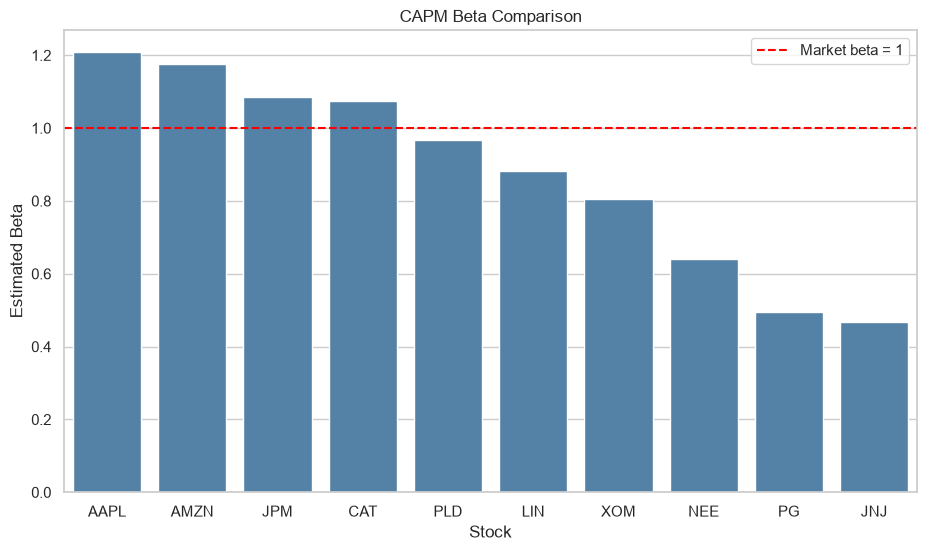

In [69]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=beta_comparison,
    x="ticker",
    y="beta",
    color="steelblue",
    ax=ax,
)

ax.axhline(
    1,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Market beta = 1",
)

ax.set_title("CAPM Beta Comparison")
ax.set_xlabel("Stock")
ax.set_ylabel("Estimated Beta")
ax.legend()

plt.show()

In [70]:
alpha_comparison = capm_results.sort_values(
    by="alpha",
    ascending=False,
).reset_index(drop=True)

alpha_comparison[
    [
        "ticker",
        "alpha",
        "alpha_pvalue",
    ]
]

alpha_comparison["alpha_significant_5pct"] = (
    alpha_comparison["alpha_pvalue"] < 0.05
)

alpha_comparison[
    [
        "ticker",
        "alpha",
        "alpha_pvalue",
        "alpha_significant_5pct",
    ]
]

,ticker,alpha,alpha_pvalue,alpha_significant_5pct
0,CAT,0.000542,0.064704,False
1,AAPL,0.000488,0.042167,True
2,AMZN,0.000367,0.241718,False
3,JPM,0.000308,0.204069,False
4,NEE,0.000294,0.296506,False
5,LIN,0.000247,0.232048,False
6,PLD,0.000166,0.520895,False
7,JNJ,0.000160,0.435283,False
8,PG,0.000102,0.622204,False
9,XOM,0.000042,0.888224,False


In [71]:
r_squared_comparison = capm_results.sort_values(
    by="r_squared",
    ascending=False,
).reset_index(drop=True)

r_squared_comparison[
    [
        "ticker",
        "r_squared",
        "adjusted_r_squared",
    ]
]

,ticker,r_squared,adjusted_r_squared
0,AAPL,0.568311,0.568139
1,JPM,0.510013,0.509818
2,LIN,0.486554,0.486350
3,AMZN,0.421577,0.421347
4,PLD,0.419349,0.419118
5,CAT,0.411689,0.411454
6,XOM,0.274060,0.273771
7,PG,0.228205,0.227897
8,JNJ,0.212836,0.212523
9,NEE,0.211857,0.211543


### Initial Findings

- AAPL has the highest estimated beta, indicating the greatest market sensitivity among the selected stocks.
- AAPL, AMZN, JPM, and CAT have betas above one.
- JNJ and PG have the lowest betas, consistent with their defensive-sector characteristics.
- AAPL has the highest R-squared, with the market explaining approximately 56.8% of its daily excess-return variation.
- AAPL's positive alpha is marginally significant at the 5% level under the baseline OLS model.
- Most stocks do not exhibit statistically significant alpha.